# GLM-5.2 vs Claude Opus 4.8 — Benchmark Results

Two complementary benchmarks on the **same repository**, both scored against
**deterministic** ground truth (a static-analysis oracle and a real test suite):

| | Benchmark 1 — **Blast Radius** | Benchmark 2 — **Debug Loop** |
|---|---|---|
| Question | "If you rename `X`, what breaks?" | "This backend bug is reported — fix it." |
| Shape | one shot, whole repo in context | agentic: tools + iterate |
| Ground truth | `grep` find-references oracle | a real failing `pytest` (SWE-bench style) |
| Measures | long-context **retrieval** | long-context **reasoning + action** |

This notebook only *visualizes* result files. Generate them first:

```bash
python run_benchmark.py              # Benchmark 1  -> results/latest.json
python run_benchmark.py --debug-loop # Benchmark 2  -> results/debug_loop_latest.json
```

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.titleweight": "bold"})

RESULTS = Path("results")
MODEL_COLORS = {"opus-4-8": "#C8643C", "glm-5-2": "#3C6EC8"}
COLOR = lambda k: MODEL_COLORS.get(k, "#888888")


def load(path):
    p = RESULTS / path
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8"))


single = load("latest.json")            # Benchmark 1
debug = load("debug_loop_latest.json")  # Benchmark 2

# Models that actually produced results (skip any without an API key).
RAN1 = {k: m for k, m in (single or {}).get("models", {}).items() if "aggregate" in m} if single else {}
RAN2 = {k: m for k, m in (debug or {}).get("models", {}).items() if "aggregate" in m} if debug else {}


def banner(tag, d, ran):
    if not d:
        print(f"[{tag}] no results file — run the benchmark first."); return
    syn = "  *** SYNTHETIC DEMO DATA ***" if d.get("synthetic") else ""
    print(f"[{tag}] mode={d.get('mode')}  generated={d.get('generated_at','?')[:19]}{syn}")
    print(f"        models: {', '.join(m['label'] for m in ran.values()) or '(none ran)'}")


banner("Benchmark 1 / Blast Radius", single, RAN1)
banner("Benchmark 2 / Debug Loop", debug, RAN2)

[Benchmark 1 / Blast Radius] mode=live  generated=2026-06-21T06:03:56
        models: Claude Opus 4.8, GLM-5.2
[Benchmark 2 / Debug Loop] mode=debug_loop  generated=2026-06-21T17:31:25
        models: Claude Opus 4.8, GLM-5.2


---
# Benchmark 1 — Blast Radius (long-context retrieval)

For each of 10 target symbols, each model is handed the **entire repository** (~130k
tokens) and asked to list every file+line a rename would touch. Scored against a
`grep` oracle, at **file** and **line** granularity.

In [2]:
# Oracle — the deterministic blast radius each model is scored against.
if single:
    oracle_df = (pd.DataFrame([{"symbol": s, "files": v["files"], "lines": v["lines"]}
                               for s, v in single["oracle"].items()])
                 .sort_values("lines", ascending=False).reset_index(drop=True))
    display(oracle_df)
    print(f"context: {single['repo']['n_files']} files, "
          f"~{single['repo']['est_tokens']:,} tokens")
else:
    print("No Benchmark 1 results.")

,symbol,files,lines
0,UserProfile,13,48
1,AgentState,11,45
2,RoutineProduct,8,27
3,ProductExtraction,8,20
4,SafetyAudit,7,20
5,MIN_INGREDIENTS_FOR_AUDIT,5,14
6,inci_names,5,11
7,PRODUCT_MATCH_THRESHOLD,3,10
8,build_initial_state,4,8
9,IDENTITY_CONFIDENCE_THRESHOLD,3,6


context: 62 files, ~130,552 tokens


In [3]:
# Build the per-model summary table for Benchmark 1.
if RAN1:
    rows = []
    for k, m in RAN1.items():
        a = m["aggregate"]
        rows.append({"model": m["label"], "key": k,
                     "file_F1": a["file"]["macro"]["f1"],
                     "file_precision": a["file"]["macro"]["precision"],
                     "file_recall": a["file"]["macro"]["recall"],
                     "line_F1": a["line"]["macro"]["f1"],
                     "line_precision": a["line"]["macro"]["precision"],
                     "line_recall": a["line"]["macro"]["recall"],
                     "mean_latency_s": a["latency_s_mean"],
                     "total_cost_usd": a["total_cost_usd"]})
    b1 = pd.DataFrame(rows).set_index("model")
    display(b1[["file_F1", "line_F1", "file_recall", "line_recall",
                "mean_latency_s", "total_cost_usd"]].round(3))
else:
    b1 = None
    print("No Benchmark 1 results.")

,file_F1,line_F1,file_recall,line_recall,mean_latency_s,total_cost_usd
model,,,,,,
Claude Opus 4.8,0.000,0.000,0.000,0.000,0.412,0.00
GLM-5.2,0.853,0.795,0.854,0.765,5.778,2.02


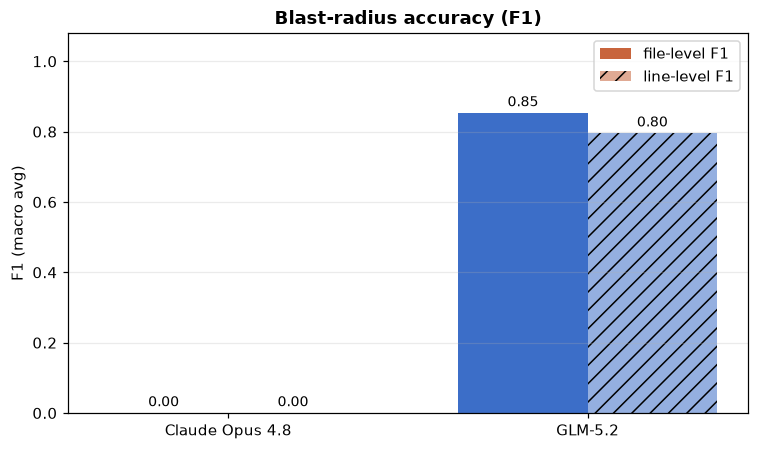

In [4]:
# Headline — file- and line-level F1 (macro-averaged across symbols).
if b1 is not None:
    fig, ax = plt.subplots(figsize=(7, 4.2))
    x = range(len(b1)); w = 0.36
    cols = [COLOR(k) for k in b1["key"]]
    ax.bar([i - w/2 for i in x], b1["file_F1"], w, color=cols, label="file-level F1")
    ax.bar([i + w/2 for i in x], b1["line_F1"], w, color=cols, alpha=0.55,
           hatch="//", label="line-level F1")
    for i, (f, l) in enumerate(zip(b1["file_F1"], b1["line_F1"])):
        ax.text(i - w/2, f + .01, f"{f:.2f}", ha="center", va="bottom", fontsize=9)
        ax.text(i + w/2, l + .01, f"{l:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(list(x)); ax.set_xticklabels(b1.index)
    ax.set_ylim(0, 1.08); ax.set_ylabel("F1 (macro avg)")
    ax.set_title("Blast-radius accuracy (F1)")
    ax.legend(); ax.grid(axis="x"); fig.tight_layout(); plt.show()

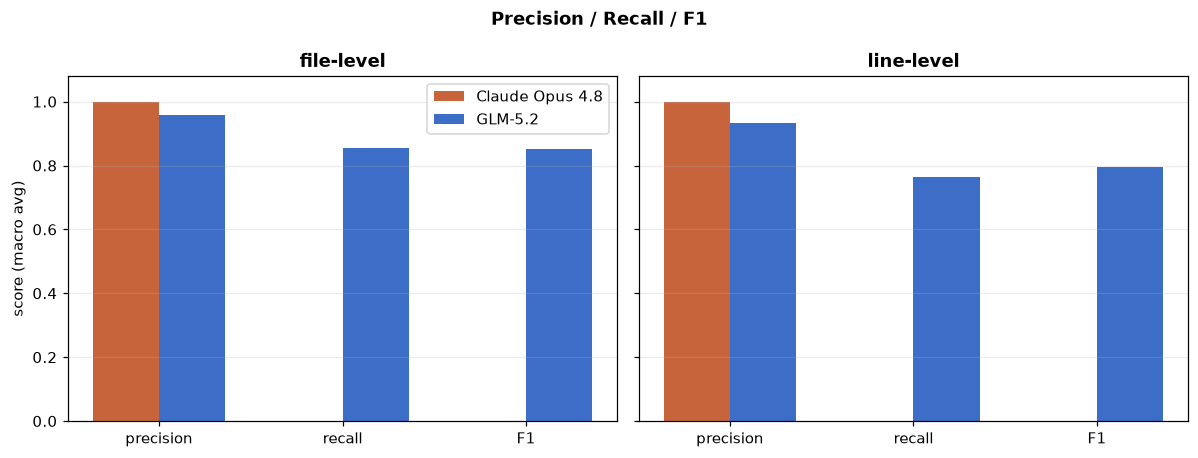

In [5]:
# Precision vs recall — file and line level side by side.
if b1 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for ax, lvl in zip(axes, ["file", "line"]):
        metrics = ["precision", "recall", "F1"]
        cols = [f"{lvl}_precision", f"{lvl}_recall", f"{lvl}_F1"]
        x = range(len(metrics)); w = 0.36
        for j, (model, row) in enumerate(b1.iterrows()):
            off = (j - (len(b1) - 1) / 2) * w
            ax.bar([i + off for i in x], [row[c] for c in cols], w,
                   label=model, color=COLOR(row["key"]))
        ax.set_xticks(list(x)); ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.08); ax.set_title(f"{lvl}-level"); ax.grid(axis="x")
    axes[0].set_ylabel("score (macro avg)"); axes[0].legend()
    fig.suptitle("Precision / Recall / F1", fontweight="bold")
    fig.tight_layout(); plt.show()

C:\Users\dvall\AppData\Local\Temp\ipykernel_11304\4133184321.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order, rotation=40, ha="right")


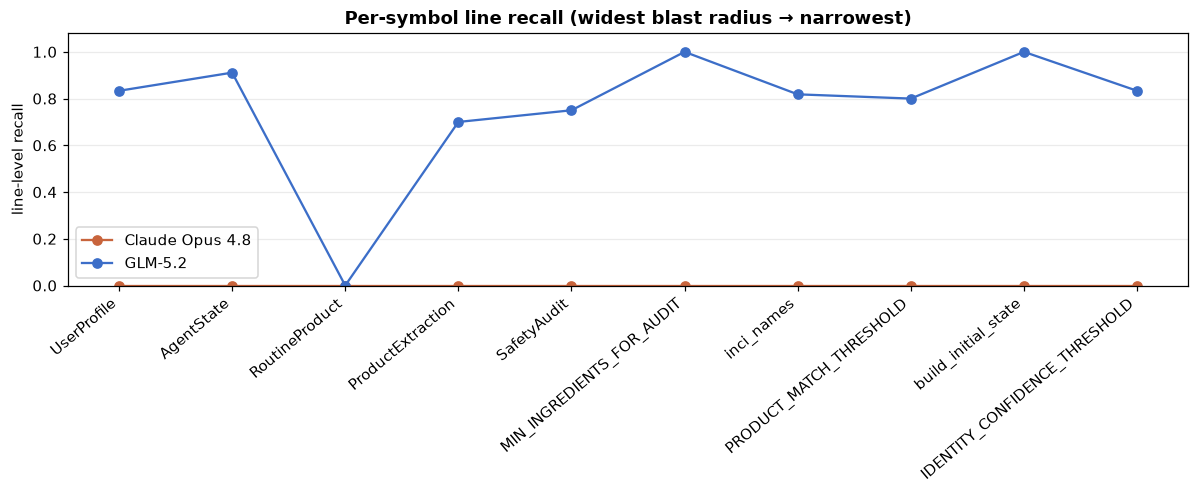

In [6]:
# Does accuracy degrade as the blast radius grows? Per-symbol line recall,
# widest symbol on the left. The stress case for a long-context model is the
# wide-blast symbol (UserProfile, AgentState): can it still find ALL 40+ refs?
if RAN1 and single:
    order = oracle_df["symbol"].tolist()
    fig, ax = plt.subplots(figsize=(11, 4.6))
    for k, m in RAN1.items():
        by = {s["symbol"]: s for s in m["per_symbol"]}
        y = [by[s]["line"]["recall"] for s in order]
        ax.plot(order, y, marker="o", color=COLOR(k), label=m["label"])
    ax.set_ylim(0, 1.08); ax.set_ylabel("line-level recall")
    ax.set_title("Per-symbol line recall (widest blast radius → narrowest)")
    ax.set_xticklabels(order, rotation=40, ha="right")
    ax.legend(); ax.grid(axis="x", alpha=0); fig.tight_layout(); plt.show()

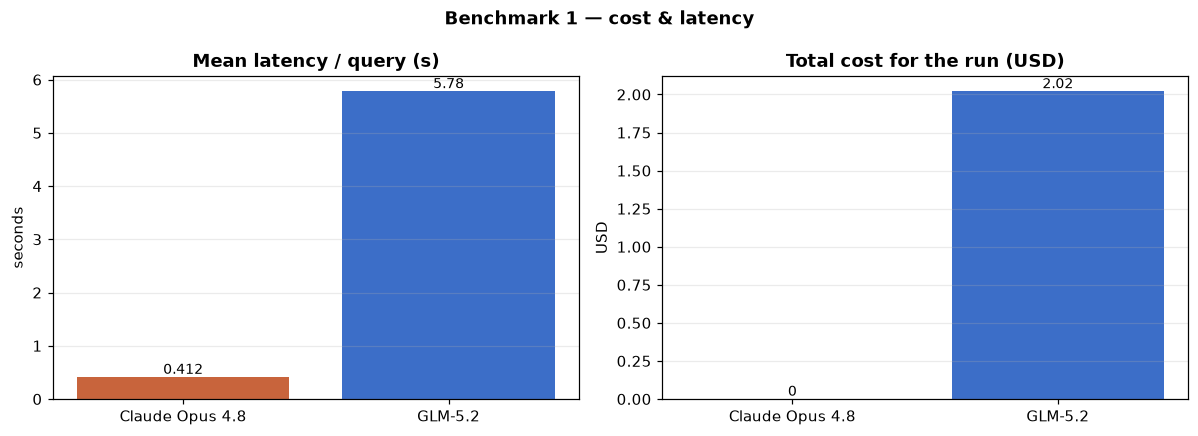

In [7]:
# The engineering trade-off: latency and cost behind that accuracy.
if b1 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    cols = [COLOR(k) for k in b1["key"]]
    axes[0].bar(b1.index, b1["mean_latency_s"], color=cols)
    axes[0].set_title("Mean latency / query (s)"); axes[0].set_ylabel("seconds")
    axes[1].bar(b1.index, b1["total_cost_usd"], color=cols)
    axes[1].set_title("Total cost for the run (USD)"); axes[1].set_ylabel("USD")
    for ax in axes:
        for i, v in enumerate(ax.containers[0].datavalues):
            ax.text(i, v, f"{v:.3g}", ha="center", va="bottom", fontsize=9)
        ax.grid(axis="x")
    fig.suptitle("Benchmark 1 — cost & latency", fontweight="bold")
    fig.tight_layout(); plt.show()
    if single.get("synthetic"):
        print("NOTE: synthetic demo — cost/latency are zero (no API calls).")

---
# Benchmark 2 — Debug Loop (agentic bug-fix)

Each model gets **tools** (`list_dir`, `read_file`, `grep`, `edit_file`, `run_tests`)
and iterates to fix a real bug in its **own isolated git worktree**, graded by a real
`pytest` run — the SWE-bench pattern.

**Scenario (commit `d11ae62`):** `POST /scan` ran the whole pipeline in one blocking
request and tripped Railway's reverse-proxy timeout. The fix adds a streaming
`POST /scan/stream` SSE endpoint. The harness checks out the buggy parent, applies only
the *test* patch, and the model must make `test_scan_stream_*` pass **without
regressing** `tests/test_api.py`.

Each model runs several independent **trials**; we report **pass@k** and efficiency
(tool calls, tokens, cost, latency).

In [8]:
# Per-model summary table for Benchmark 2.
if RAN2:
    rows = []
    for k, m in RAN2.items():
        a = m["aggregate"]
        rows.append({"model": m["label"], "key": k,
                     "trials": a["trials"], "passes": a["passes"],
                     "pass@1": a["pass_at_1"],
                     "cost_per_pass_usd": a["cost_per_pass_usd"],
                     "median_cost_usd": a["median_cost_usd"],
                     "median_tool_calls": a["median_tool_calls"],
                     "median_total_tokens": a["median_total_tokens"],
                     "median_latency_s": a["median_latency_s"],
                     "harness_errors": a["n_harness_errors"]})
    b2 = pd.DataFrame(rows).set_index("model")
    sc = debug.get("scenario", {})
    print(f"scenario: fix={sc.get('fix_commit')}  target=`{sc.get('verdict_target')}`  "
          f"trials={sc.get('trials')}  step budget={sc.get('step_budget')}")
    display(b2.drop(columns="key"))
else:
    b2 = None
    print("No Benchmark 2 results — run `python run_benchmark.py --debug-loop`.")

scenario: fix=d11ae62  target=`scan_stream`  trials=5  step budget=15


,trials,passes,pass@1,cost_per_pass_usd,median_cost_usd,median_tool_calls,median_total_tokens,median_latency_s,harness_errors
model,,,,,,,,,
Claude Opus 4.8,5,5,1.0,0.612946,0.608498,14,299605,150.85,0
GLM-5.2,5,2,0.4,1.655903,0.622563,21,401217,241.68,0


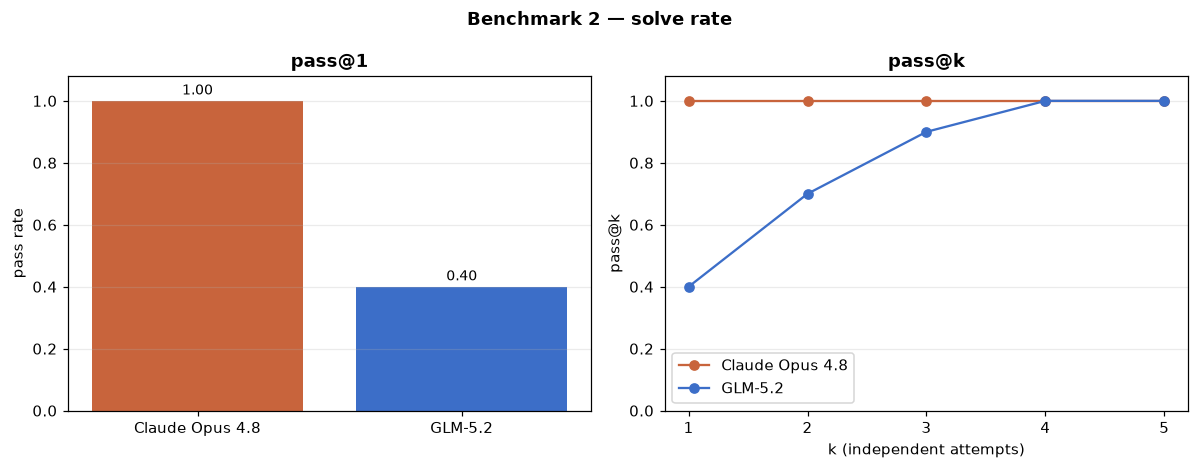

In [9]:
# pass@1 (left) and the pass@k curve (right). pass@k = probability that at least
# one of k independent attempts yields a passing fix (unbiased, Chen et al. 2021).
if b2 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    cols = [COLOR(k) for k in b2["key"]]
    axes[0].bar(b2.index, b2["pass@1"], color=cols)
    axes[0].set_ylim(0, 1.08); axes[0].set_title("pass@1"); axes[0].set_ylabel("pass rate")
    for i, v in enumerate(b2["pass@1"]):
        axes[0].text(i, v + .01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    axes[0].grid(axis="x")
    for k, m in RAN2.items():
        pk = m["aggregate"]["pass_at_k"]
        ks = sorted(int(i) for i in pk)
        axes[1].plot(ks, [pk[str(i)] for i in ks], marker="o",
                     color=COLOR(k), label=m["label"])
    axes[1].set_ylim(0, 1.08); axes[1].set_xlabel("k (independent attempts)")
    axes[1].set_ylabel("pass@k"); axes[1].set_title("pass@k")
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[1].legend(); axes[1].grid(axis="x", alpha=0)
    fig.suptitle("Benchmark 2 — solve rate", fontweight="bold")
    fig.tight_layout(); plt.show()

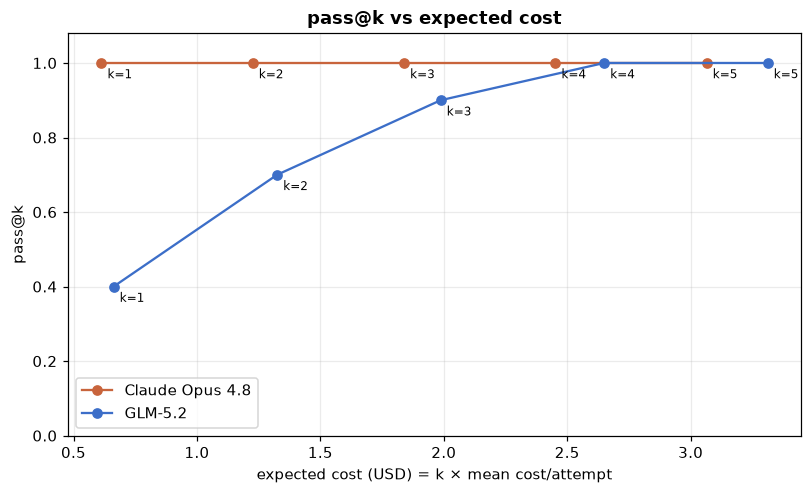

NOTE: GLM cost is indicative when run via Ollama Cloud (subscription billing).


In [10]:
# The money chart: pass@k vs expected $ spend. "If I'm willing to sample k times,
# what does a passing fix cost?" — the decision an auto-fixer in CI actually makes.
if RAN2:
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    for k, m in RAN2.items():
        curve = m["aggregate"]["pass_at_k_vs_cost"]
        xs = [c["expected_cost_usd"] for c in curve]
        ys = [c["pass_at_k"] for c in curve]
        ax.plot(xs, ys, marker="o", color=COLOR(k), label=m["label"])
        for c in curve:
            ax.annotate(f"k={c['k']}", (c["expected_cost_usd"], c["pass_at_k"]),
                        textcoords="offset points", xytext=(4, -10), fontsize=8)
    ax.set_xlabel("expected cost (USD) = k × mean cost/attempt")
    ax.set_ylabel("pass@k"); ax.set_ylim(0, 1.08)
    ax.set_title("pass@k vs expected cost")
    ax.legend(); fig.tight_layout(); plt.show()
    print("NOTE: GLM cost is indicative when run via Ollama Cloud (subscription billing).")

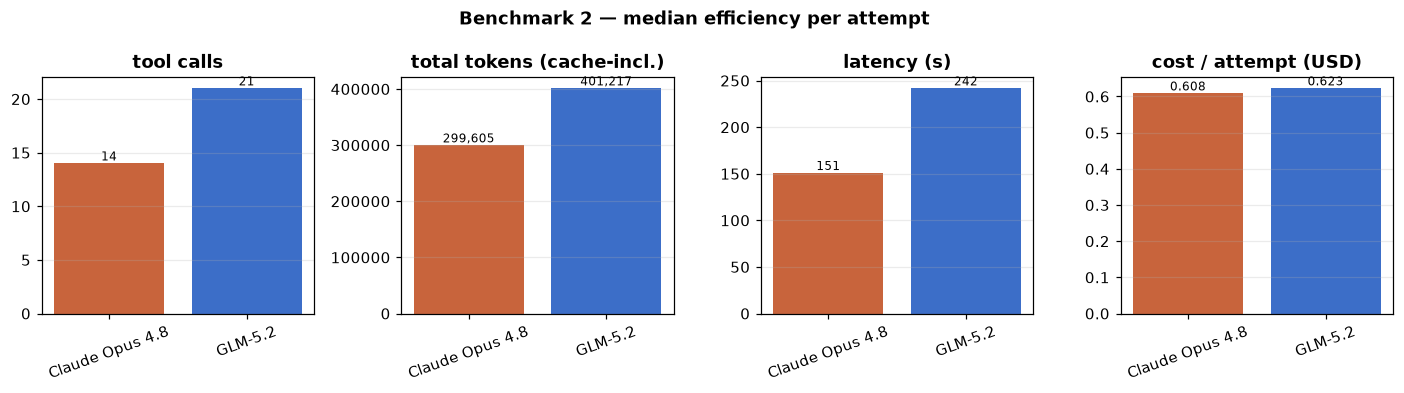

In [11]:
# Efficiency profile — medians across trials. Tool-calls/tokens (not steps) are the
# fair effort axis: Opus batches several tool calls into one step.
if b2 is not None:
    panels = [("median_tool_calls", "tool calls", "{:.0f}"),
              ("median_total_tokens", "total tokens (cache-incl.)", "{:,.0f}"),
              ("median_latency_s", "latency (s)", "{:.0f}"),
              ("median_cost_usd", "cost / attempt (USD)", "{:.3f}")]
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
    cols = [COLOR(k) for k in b2["key"]]
    for ax, (col, title, fmt) in zip(axes, panels):
        ax.bar(b2.index, b2[col], color=cols)
        ax.set_title(title)
        for i, v in enumerate(b2[col]):
            ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
        ax.tick_params(axis="x", rotation=20); ax.grid(axis="x")
    fig.suptitle("Benchmark 2 — median efficiency per attempt", fontweight="bold")
    fig.tight_layout(); plt.show()

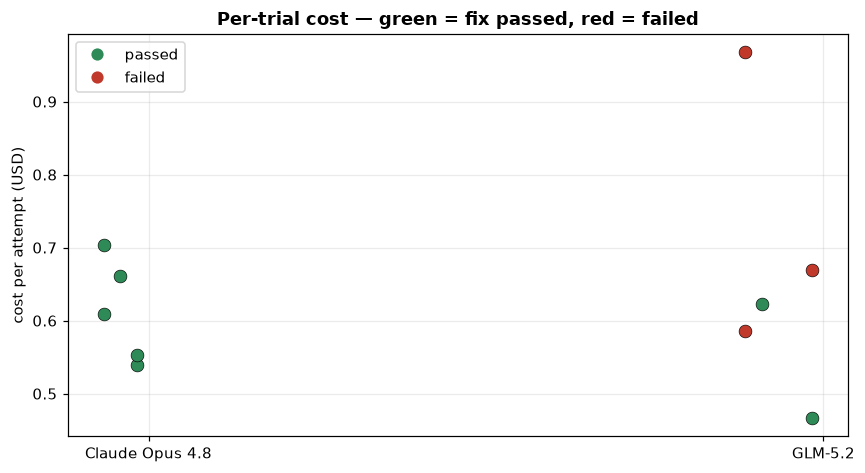

In [12]:
# Per-trial spread: cost of every attempt, green = passed, red = failed.
# Shows consistency, not just the median.
if RAN2:
    fig, ax = plt.subplots(figsize=(8, 4.4))
    labels = []
    for xi, (k, m) in enumerate(RAN2.items()):
        labels.append(m["label"])
        for t in m["trials"]:
            jitter = (hash(t.get("model_id", "")) % 7 - 3) / 30 + (id(t) % 5 - 2) / 40
            ax.scatter(xi + jitter, t["total_cost_usd"],
                       color=("#2E8B57" if t.get("success") else "#C0392B"),
                       edgecolor="k", linewidth=0.4, s=70, zorder=3)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_ylabel("cost per attempt (USD)")
    ax.set_title("Per-trial cost — green = fix passed, red = failed")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0], [0], marker="o", color="w", label="passed",
                              markerfacecolor="#2E8B57", markersize=9),
                       Line2D([0], [0], marker="o", color="w", label="failed",
                              markerfacecolor="#C0392B", markersize=9)])
    fig.tight_layout(); plt.show()

---
## Read-out

Fill in from the live numbers above (these are the points engineers will want):

- **Long-context retrieval (B1):** file-level F1 is the headline — can the model tell
  you which files to touch? Line-level recall on the *wide-blast* symbols is the real
  stress test of reading a 130k-token context.
- **Agentic reasoning (B2):** pass@1 and the pass@k curve say whether the model can
  actually *fix* a bug end-to-end; the pass@k-vs-cost chart says what that costs.
- **Efficiency:** tool-calls and tokens-per-attempt show *how* each model gets there
  (more iteration vs. fewer, sharper edits).
- **Cost caveat:** Opus costs are exact (prompt-cached); GLM via Ollama Cloud is
  subscription-billed, so its dollar figures are indicative.

Every number here is reproducible — the oracle and the pytest verdict are deterministic,
so re-running the benchmarks reproduces these results.